# 🛒 Customer Segmentation using Machine Learning
### An End-to-End K-Means Clustering Project on Ecommerce Customer Behavior Data

**Prepared by:** Data Science Team
**Project Type:** Unsupervised Machine Learning — Customer Segmentation
**Algorithm Used:** K-Means Clustering

---

## 1. Project Overview

Understanding customers is at the heart of every successful ecommerce business. Not all customers behave the same way — some shop frequently and spend generously, others visit rarely but are highly loyal, and some are at risk of churning altogether. Treating every customer identically wastes marketing budget and misses opportunities to nurture high-value relationships.

This project applies **unsupervised machine learning (K-Means Clustering)** to group customers into distinct, meaningful segments based on their demographic profile and behavioral patterns (purchase habits, engagement, loyalty, and spending).

## 2. Business Objective

- Segment the customer base into actionable groups.
- Identify **high-value**, **loyal**, **at-risk**, and **budget-conscious** customers.
- Provide **data-driven marketing and retention recommendations** for each segment.
- Support strategic decisions around promotions, loyalty programs, and customer retention.

## 3. Dataset Description

The dataset used is an **Ecommerce Customer Behavior dataset** containing **50,000 customer records** and **25 attributes**, covering:

- **Demographics:** Age, Gender, Country, City
- **Engagement:** Login Frequency, Session Duration, Pages per Session, Email Open Rate, Mobile App Usage
- **Purchase Behavior:** Total Purchases, Average Order Value, Days Since Last Purchase, Discount Usage, Returns Rate
- **Loyalty & Value:** Membership Years, Lifetime Value, Credit Balance, Payment Method Diversity
- **Outcome flag:** Churned (0 = retained, 1 = churned) — used only for post-segmentation validation, *not* as a clustering input.

> **Note:** This dataset does not contain a pre-built `Customer_Satisfaction` score. Where the project brief calls for a "Customer Satisfaction Distribution," we use **Email Open Rate** as a reasonable behavioral proxy for engagement/satisfaction, since it reflects how positively a customer responds to brand communication. This substitution is clearly labeled throughout the notebook.

## 4. Project Workflow

1. Data Loading & Initial Inspection
2. Exploratory Data Analysis (EDA)
3. Data Cleaning & Preprocessing
4. Feature Engineering & Selection
5. Feature Scaling
6. Optimal Cluster Selection (Elbow Method + Silhouette Score)
7. K-Means Model Building
8. Cluster Profiling & Visualization
9. Business Insights & Recommendations
10. Exporting the Segmented Dataset


## 5. Importing Required Libraries

We import all the libraries needed for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`), preprocessing and clustering (`scikit-learn`), and suppress non-critical warnings for a clean notebook output.

In [1]:
# Core data handling libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Machine Learning - preprocessing and clustering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Utility
import warnings
warnings.filterwarnings('ignore')

# Global plotting style for professional, consistent visuals
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 6. Loading the Dataset

We load the raw CSV file into a pandas DataFrame. This is the single source of truth for the entire analysis.

In [2]:
# Load the ecommerce customer dataset
df = pd.read_csv('ecommerce_customer_churn_dataset.csv')

print(f"Dataset loaded successfully with {df.shape[0]:,} rows and {df.shape[1]} columns.")

Dataset loaded successfully with 50,000 rows and 25 columns.


## 7. Initial Data Inspection

Before any analysis, we perform a first-pass inspection of the dataset: first/last rows, shape, structure, column names, data types, and descriptive statistics. This gives us a baseline understanding of what we are working with.

### 7.1 First 5 Rows

In [3]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


### 7.2 Last 5 Rows

In [4]:
df.tail()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
49995,38.0,Female,USA,Los Angeles,10.0,10.0,35.8,8.8,51.2,3.0,...,9.2,5.0,1.0,20.7,25.2,1.0,2365.98,3499.0,0,Q2
49996,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,2.0,...,17.6,5.0,3.0,38.6,12.1,4.0,1293.60,3154.0,0,Q3
49997,44.0,Female,USA,Phoenix,2.8,19.0,40.3,10.4,50.6,1.0,...,25.2,4.0,6.0,59.9,NaN,1.0,1655.28,1622.0,0,Q1
49998,41.0,Female,USA,Chicago,2.9,17.0,29.9,10.1,60.8,1.0,...,34.6,5.0,2.0,NaN,14.1,3.0,1286.11,2634.0,0,Q2
49999,56.0,Male,UK,Leeds,2.2,2.0,18.2,NaN,46.0,0.0,...,0.0,7.0,0.0,0.0,4.2,1.0,1072.61,612.0,0,Q3


### 7.3 Dataset Shape

In [5]:
print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]}")

Number of rows    : 50,000
Number of columns : 25


### 7.4 Dataset Information (dtypes, non-null counts, memory usage)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  str    
 2   Country                        50000 non-null  str    
 3   City                           50000 non-null  str    
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null  float64
 1

### 7.5 Column Names

In [7]:
print(list(df.columns))

['Age', 'Gender', 'Country', 'City', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance', 'Churned', 'Signup_Quarter']


### 7.6 Data Types

In [8]:
df.dtypes

Age                              float64
Gender                               str
Country                              str
City                                 str
Membership_Years                 float64
Login_Frequency                  float64
Session_Duration_Avg             float64
Pages_Per_Session                float64
Cart_Abandonment_Rate            float64
Wishlist_Items                   float64
Total_Purchases                  float64
Average_Order_Value              float64
Days_Since_Last_Purchase         float64
Discount_Usage_Rate              float64
Returns_Rate                     float64
Email_Open_Rate                  float64
Customer_Service_Calls           float64
Product_Reviews_Written          float64
Social_Media_Engagement_Score    float64
Mobile_App_Usage                 float64
Payment_Method_Diversity         float64
Lifetime_Value                   float64
Credit_Balance                   float64
Churned                            int64
Signup_Quarter  

### 7.7 Descriptive Statistics

`describe()` with `include='all'` gives us summary statistics for **both** numerical and categorical columns in one view.

In [9]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,47505.0,NaN,NaN,NaN,37.802968,11.834668,5.0,29.0,38.0,46.0,200.0
Gender,50000,3,Female,25116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,50000,8,USA,17384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,50000,40,Houston,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Membership_Years,50000.0,NaN,NaN,NaN,2.984009,2.059105,0.1,1.4,2.5,4.0,10.0
Login_Frequency,50000.0,NaN,NaN,NaN,11.62466,7.810657,0.0,6.0,11.0,17.0,46.0
Session_Duration_Avg,46601.0,NaN,NaN,NaN,27.660754,10.871013,1.0,19.7,26.8,34.7,75.6
Pages_Per_Session,47000.0,NaN,NaN,NaN,8.737811,3.77822,1.0,6.0,8.4,11.2,24.1
Cart_Abandonment_Rate,50000.0,NaN,NaN,NaN,57.079973,16.282723,0.0,46.4,58.1,68.7,143.74335
Wishlist_Items,46000.0,NaN,NaN,NaN,4.298391,3.189754,0.0,2.0,4.0,6.0,28.0


**Initial Observations:**
- The dataset has **50,000 rows and 25 columns** — a mix of numerical behavioral metrics and categorical demographic fields.
- Several numerical columns (`Age`, `Session_Duration_Avg`, `Wishlist_Items`, `Returns_Rate`, `Social_Media_Engagement_Score`, `Credit_Balance`, etc.) show a `count` below 50,000, indicating **missing values** that must be handled.
- `Age` has a maximum value of **200**, which is not biologically realistic and signals a **data quality / outlier issue** to correct.
- `Cart_Abandonment_Rate` and a few other "rate" columns exceed 100 in places, even though rates are conceptually bounded at 100%, again pointing to outliers.
- `Churned` is a binary flag (0/1) — we will retain it for **post-segmentation validation only**, not as an input to clustering (since clustering must group customers by *behavior*, not by the outcome we might want to explain).

## 8. Exploratory Data Analysis (EDA)

In this section we systematically explore the dataset to understand data quality issues (missing values, duplicates), the distribution of categorical and numerical variables, and the presence of outliers. Every observation is explained so that preprocessing decisions later in the notebook are well justified.

### 8.1 Missing Values Check

In [10]:
missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)
missing_summary

,Missing_Count,Missing_Percent
Social_Media_Engagement_Score,6000,12.00
Credit_Balance,5500,11.00
Mobile_App_Usage,5000,10.00
Returns_Rate,4491,8.98
Wishlist_Items,4000,8.00
Discount_Usage_Rate,3500,7.00
Product_Reviews_Written,3500,7.00
Session_Duration_Avg,3399,6.80
Pages_Per_Session,3000,6.00
Days_Since_Last_Purchase,3000,6.00


**Observation:** Missing values are present in 16 columns, ranging from under 1% (`Customer_Service_Calls`) to as high as ~12% (`Social_Media_Engagement_Score`, `Credit_Balance`). None of the columns are missing so extensively that they need to be dropped entirely; instead, we will impute them appropriately during preprocessing.

### 8.2 Duplicate Records Check

In [11]:
duplicate_count = df.duplicated().sum()
print(f"Number of fully duplicated rows: {duplicate_count}")

Number of fully duplicated rows: 0


**Observation:** There are no fully duplicated rows in the raw dataset. We will still include a duplicate-removal step in preprocessing as a defensive best practice.

### 8.3 Unique Values per Column

In [12]:
unique_summary = pd.DataFrame({
    'Unique_Values': df.nunique(),
    'Dtype': df.dtypes.astype(str)
}).sort_values('Unique_Values')
unique_summary

,Unique_Values,Dtype
Churned,2,int64
Gender,3,str
Signup_Quarter,4,str
Payment_Method_Diversity,5,float64
Country,8,str
Product_Reviews_Written,18,float64
Customer_Service_Calls,21,float64
Wishlist_Items,25,float64
City,40,str
Login_Frequency,46,float64


**Observation:** `Gender` (3 categories), `Country` (8 categories), `Signup_Quarter` (4 categories) and `Churned` (2 categories) are low-cardinality categorical fields well suited for encoding. `City` has 40 unique values — moderately high cardinality, so it will be excluded from clustering to avoid excessive dimensionality, but Country-level geography is retained.

### 8.4 Categorical Variable Analysis

In [13]:
categorical_cols = ['Gender', 'Country', 'Signup_Quarter']

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- Gender ---
Gender
Female    25116
Male      23947
Other       937
Name: count, dtype: int64

--- Country ---
Country
USA          17384
UK            7534
Canada        6023
Germany       4925
Australia     4061
France        4013
India         3512
Japan         2548
Name: count, dtype: int64

--- Signup_Quarter ---
Signup_Quarter
Q3    12558
Q2    12521
Q4    12468
Q1    12453
Name: count, dtype: int64



**Observations:**
- **Gender:** The customer base is fairly balanced between Female (~50%) and Male (~48%), with a small "Other" category (~2%).
- **Country:** USA dominates the customer base (~35%), followed by UK, Canada, Germany, Australia, France, India, and Japan — a broadly international customer base weighted toward North America and Europe.
- **Signup_Quarter:** Signups are evenly distributed across all four quarters (~25% each), suggesting no strong seasonality in customer acquisition.

### 8.5 Numerical Variable Analysis

In [14]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('Churned')  # binary flag, not a continuous behavioral metric
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,47505.0,37.802968,11.834668,5.00,29.0000,38.000,46.00,200.000000
Membership_Years,50000.0,2.984009,2.059105,0.10,1.4000,2.500,4.00,10.000000
Login_Frequency,50000.0,11.624660,7.810657,0.00,6.0000,11.000,17.00,46.000000
Session_Duration_Avg,46601.0,27.660754,10.871013,1.00,19.7000,26.800,34.70,75.600000
Pages_Per_Session,47000.0,8.737811,3.778220,1.00,6.0000,8.400,11.20,24.100000
Cart_Abandonment_Rate,50000.0,57.079973,16.282723,0.00,46.4000,58.100,68.70,143.743350
Wishlist_Items,46000.0,4.298391,3.189754,0.00,2.0000,4.000,6.00,28.000000
Total_Purchases,50000.0,13.111576,7.017312,-13.00,8.0000,12.000,17.00,128.700000
Average_Order_Value,50000.0,123.117330,175.569714,26.38,87.0500,112.970,144.44,9666.379178
Days_Since_Last_Purchase,47000.0,29.792872,29.695062,0.00,9.0000,21.000,41.00,287.000000


**Observations:**
- `Age` ranges up to 200 — clearly invalid entries that need correction.
- `Lifetime_Value` and `Average_Order_Value` are right-skewed with long tails, typical of spending data where a minority of customers spend disproportionately more.
- `Days_Since_Last_Purchase` has a wide spread (up to 287 days), which will be useful for identifying at-risk / dormant customers.
- `Cart_Abandonment_Rate`, `Discount_Usage_Rate`, and `Returns_Rate` are percentage-based metrics that occasionally exceed the logical 0–100 bound, confirming the outliers flagged earlier.

### 8.6 Outlier Detection

In [15]:
# Use the IQR method to flag potential outliers in key numerical columns
outlier_check_cols = ['Age', 'Lifetime_Value', 'Average_Order_Value', 'Cart_Abandonment_Rate', 'Total_Purchases']

outlier_report = {}
for col in outlier_check_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = n_outliers

pd.DataFrame.from_dict(outlier_report, orient='index', columns=['Outlier_Count'])

,Outlier_Count
Age,126
Lifetime_Value,1684
Average_Order_Value,1005
Cart_Abandonment_Rate,323
Total_Purchases,628


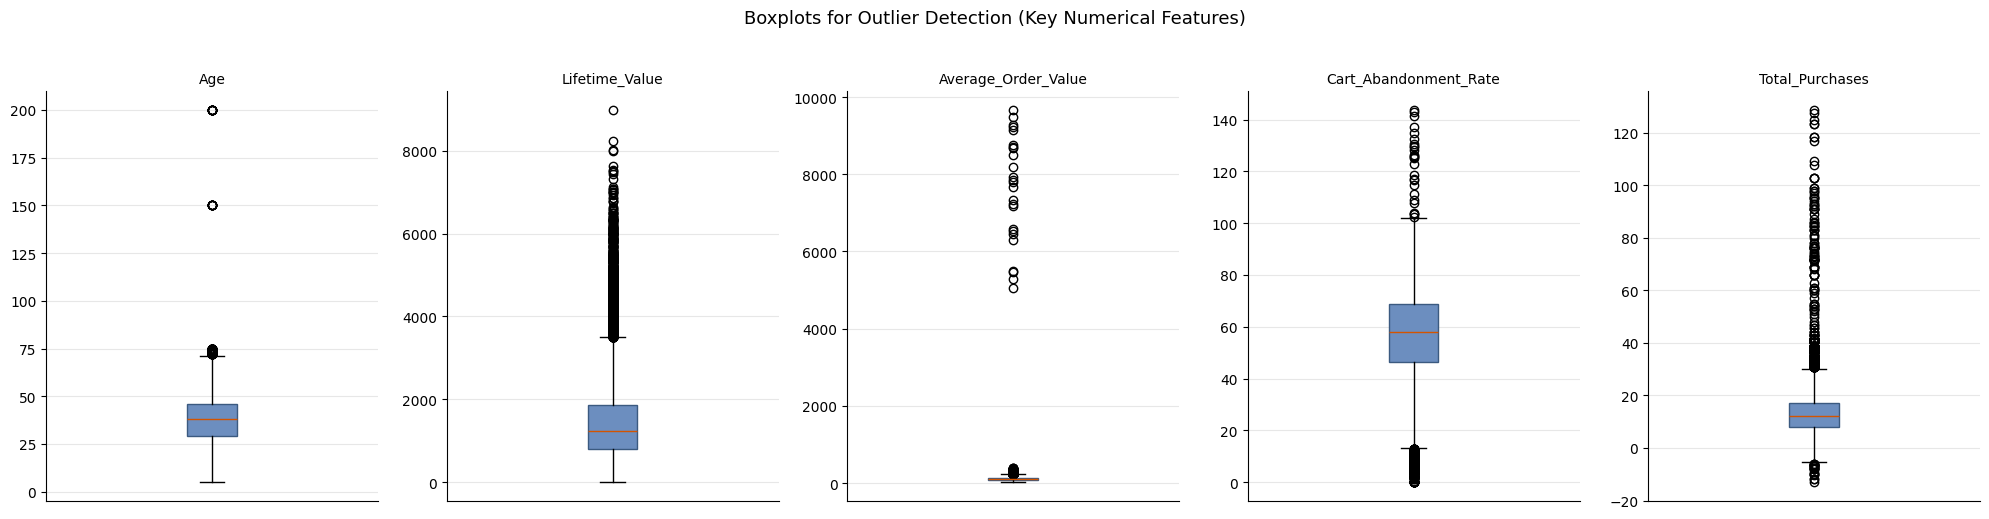

In [16]:
# Visualize outliers with boxplots
fig, axes = plt.subplots(1, len(outlier_check_cols), figsize=(20, 5))
for ax, col in zip(axes, outlier_check_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#6C8EBF', color='#3B5A80'),
               medianprops=dict(color='#D35400'))
    ax.set_title(col, fontsize=10)
    ax.set_xticks([])
fig.suptitle('Boxplots for Outlier Detection (Key Numerical Features)', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

**Observation:** `Age` and `Cart_Abandonment_Rate` show the presence of illogical values (e.g., ages above 100, rates above 100%). `Lifetime_Value`, `Average_Order_Value`, and `Total_Purchases` show statistical outliers on the high end — these represent genuinely high-spending customers rather than data errors, so we will **cap** (not delete) the illogical values while **preserving** legitimate high-value customer records, since removing them would bias the segmentation against exactly the high-value customers the business cares about most.

## 9. Distribution Visualizations

We now visualize the distribution of key demographic and behavioral variables to build visual intuition before modeling.

### 9.1 Age Distribution

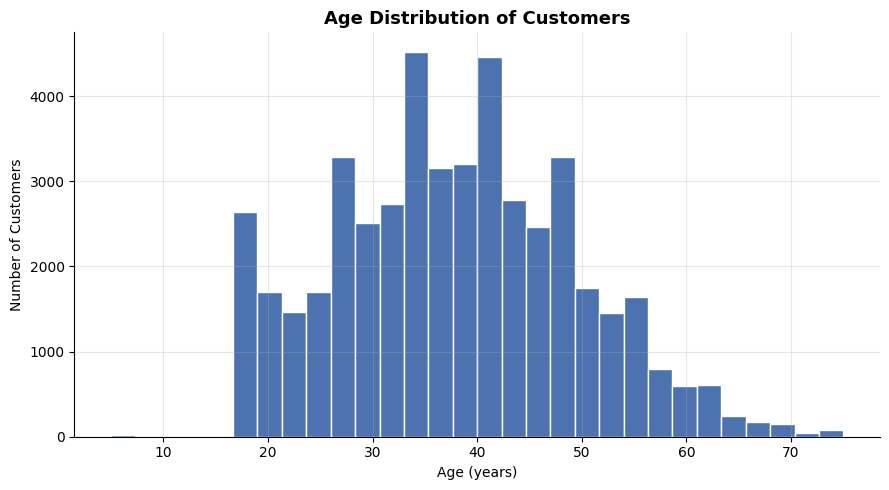

In [17]:
plt.figure(figsize=(9, 5))
plt.hist(df.loc[df['Age'] <= 100, 'Age'].dropna(), bins=30, color='#4C72B0', edgecolor='white')
plt.title('Age Distribution of Customers', fontsize=13, fontweight='bold')
plt.xlabel('Age (years)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

**Observation:** Customer age is broadly spread between 18 and 70 years, with a concentration in the 30–50 range — the core working-age demographic that typically drives ecommerce spending.

### 9.2 Gender Distribution

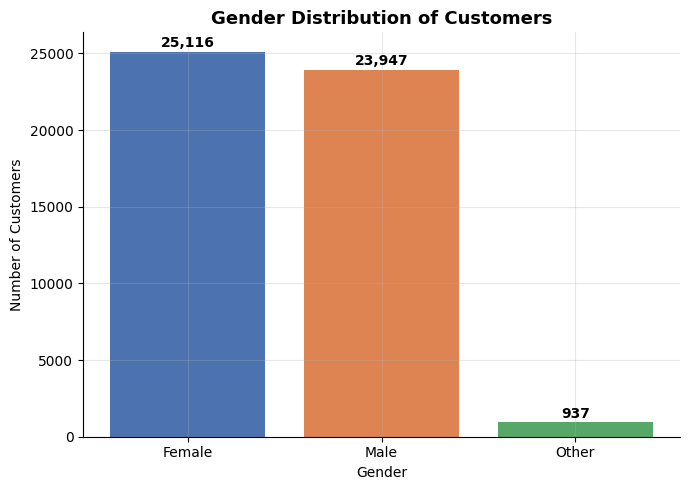

In [18]:
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(7, 5))
plt.bar(gender_counts.index, gender_counts.values, color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Gender Distribution of Customers', fontsize=13, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
for i, v in enumerate(gender_counts.values):
    plt.text(i, v + 300, f"{v:,}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** The customer base is nearly evenly split between Female and Male customers, with a small but meaningful \"Other\" segment — confirming an inclusive and broadly balanced audience.

### 9.3 Total Spend Distribution

`Lifetime_Value` represents each customer's cumulative spend with the business and is used here as the "Total Spend" metric.

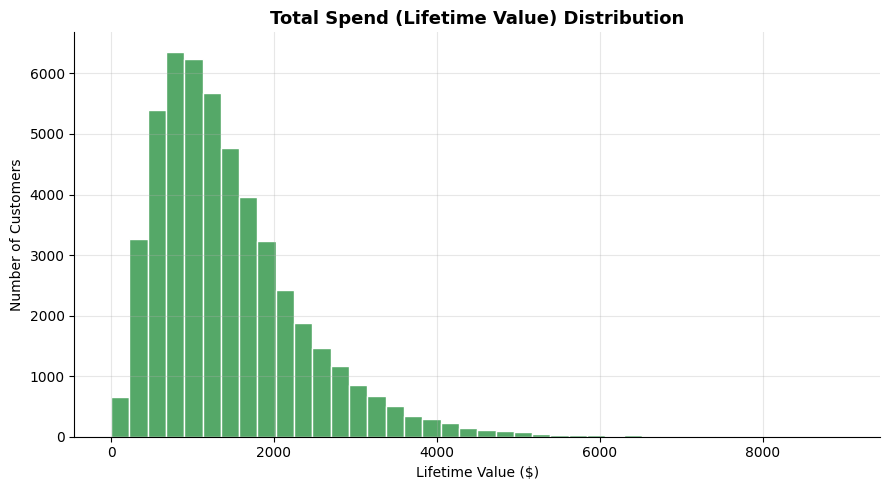

In [19]:
plt.figure(figsize=(9, 5))
plt.hist(df['Lifetime_Value'].dropna(), bins=40, color='#55A868', edgecolor='white')
plt.title('Total Spend (Lifetime Value) Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Lifetime Value ($)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

**Observation:** Lifetime Value is right-skewed — most customers cluster in the low-to-mid spending range, while a smaller group of high-value customers extends the tail well beyond $5,000. This is the classic ecommerce spending pattern and hints that a meaningful \"premium\" segment likely exists.

### 9.4 Purchase Frequency Distribution

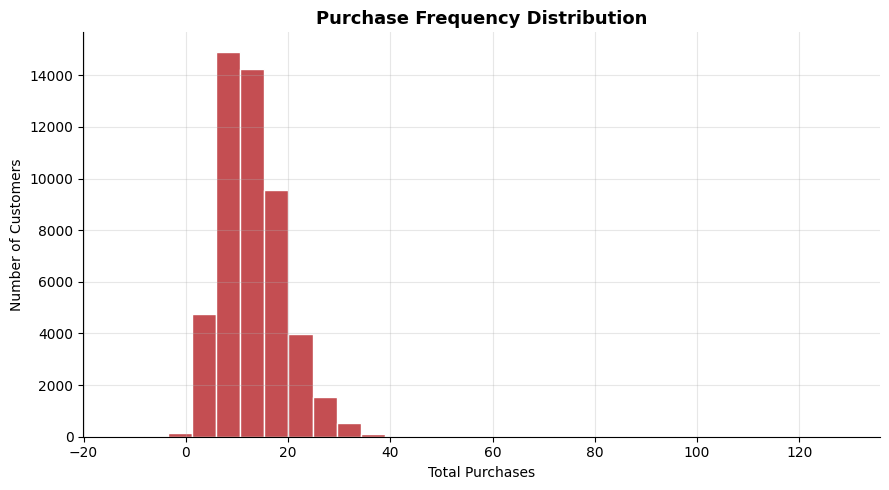

In [20]:
plt.figure(figsize=(9, 5))
plt.hist(df['Total_Purchases'].dropna(), bins=30, color='#C44E52', edgecolor='white')
plt.title('Purchase Frequency Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Total Purchases')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

**Observation:** Purchase frequency is also right-skewed, with the majority of customers making a modest number of purchases and a smaller tail of highly frequent, repeat buyers.

### 9.5 Customer Satisfaction Distribution (Proxy: Email Open Rate)

As noted earlier, the dataset has no direct satisfaction score, so `Email_Open_Rate` is used as a behavioral proxy for engagement/satisfaction with the brand.

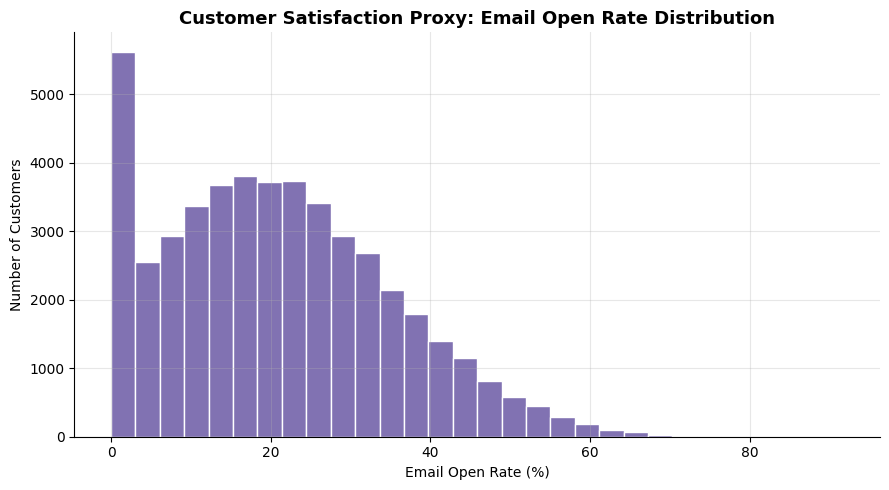

In [21]:
plt.figure(figsize=(9, 5))
plt.hist(df['Email_Open_Rate'].dropna(), bins=30, color='#8172B2', edgecolor='white')
plt.title('Customer Satisfaction Proxy: Email Open Rate Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Email Open Rate (%)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

**Observation:** Email open rates are fairly spread out across the 0–90% range without a single dominant peak, suggesting engagement levels vary considerably across the customer base — a useful signal for segmentation.

### 9.6 Correlation Heatmap

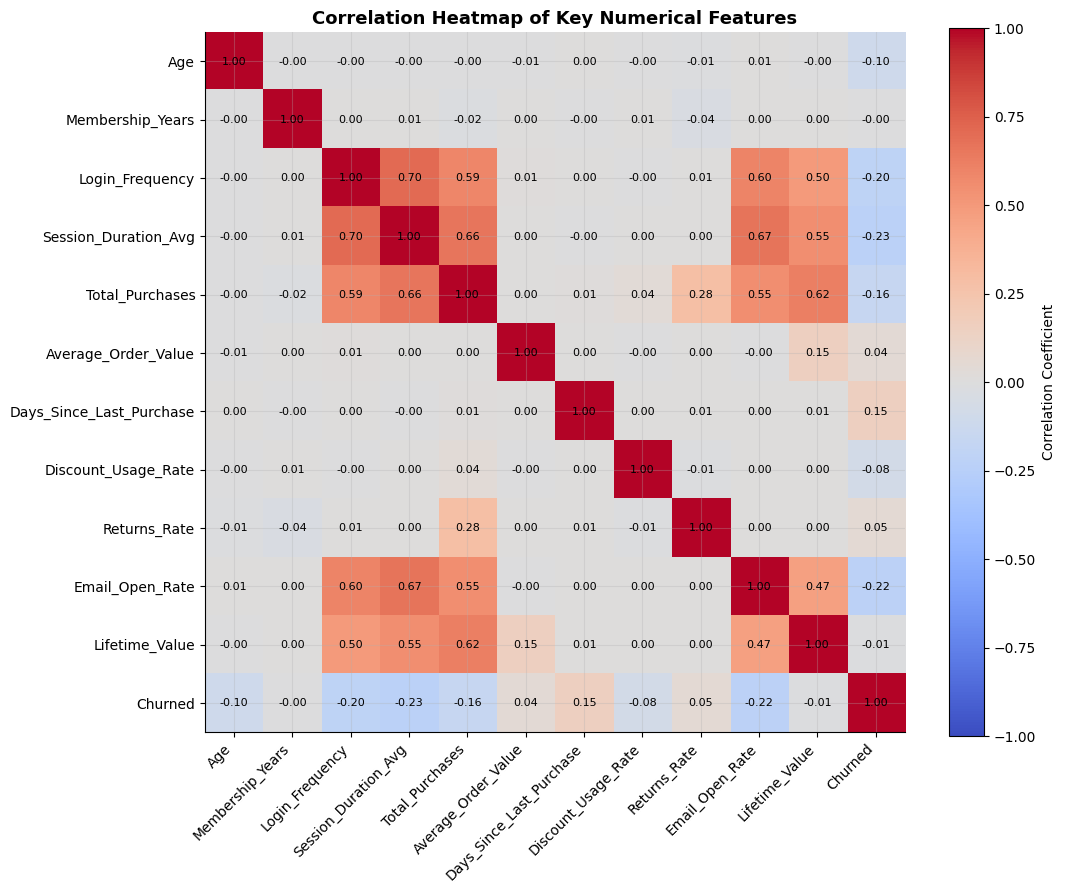

In [22]:
corr_cols = ['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg',
             'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase',
             'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Lifetime_Value', 'Churned']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)

# Annotate cells with correlation values
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center',
                color='black', fontsize=8)

plt.colorbar(im, ax=ax, label='Correlation Coefficient')
plt.title('Correlation Heatmap of Key Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Correlations among most behavioral features are relatively mild, meaning each variable contributes distinct, non-redundant information — a good sign for clustering, which benefits from features that aren't all measuring the same underlying signal. `Total_Purchases`, `Average_Order_Value`, and `Lifetime_Value` show a positive relationship, as expected, since Lifetime Value is mathematically related to purchase volume and order size.

## 10. Data Preprocessing

Based on the EDA findings above, we now clean and prepare the data for modeling. Each step below is explained and justified.

### 10.1 Handling Missing Values

We impute missing values using the **median** for numerical columns, since the median is robust to the outliers and skew we identified during EDA (mean would be pulled by extreme high-spend customers). There are no missing values in categorical columns, so no categorical imputation is required.

In [23]:
df_clean = df.copy()

# Identify numerical columns with missing values (excluding the target-like 'Churned' flag)
num_cols_missing = [c for c in df_clean.select_dtypes(include=[np.number]).columns
                     if c != 'Churned' and df_clean[c].isnull().sum() > 0]

for col in num_cols_missing:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

print("Remaining missing values after imputation:")
print(df_clean.isnull().sum().sum())

Remaining missing values after imputation:
0


### 10.2 Removing Duplicate Records

Although the earlier check found no exact duplicates, we apply `drop_duplicates()` defensively — a standard best practice in any production-grade data pipeline.

In [24]:
before_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
after_rows = len(df_clean)

print(f"Rows before: {before_rows:,} | Rows after: {after_rows:,} | Removed: {before_rows - after_rows}")

Rows before: 50,000 | Rows after: 50,000 | Removed: 0


### 10.3 Correcting Invalid Values / Outlier Capping

We correct three known data quality issues identified in EDA:
- `Age` values above 100 are biologically implausible for an ecommerce customer base — we cap `Age` at a sensible upper bound of 90 years.
- Percentage-based "rate" columns (`Cart_Abandonment_Rate`, `Discount_Usage_Rate`, `Returns_Rate`) are conceptually bounded between 0 and 100 — we clip any values outside this logical range.
- Monetary/behavioral columns used in clustering (`Average_Order_Value`, `Lifetime_Value`, `Total_Purchases`) contain a small number of extreme statistical outliers (e.g. an order value of \$9,666 against a 75th percentile of ~\$144). Left untouched, distance-based K-Means is highly sensitive to such extreme points and will isolate them into a degenerate, statistically meaningless micro-cluster of only a handful of customers instead of producing genuinely actionable segments. We apply **IQR-based winsorization** (capping at Q1 - 1.5x IQR / Q3 + 1.5x IQR) to these columns -- this preserves every record (no deletion) while preventing a tiny number of extreme values from distorting the entire cluster geometry.

We use **capping/clipping rather than deletion** throughout so that we do not lose legitimate data from otherwise valid customer records.

In [25]:
# Cap Age at a realistic upper bound
df_clean['Age'] = df_clean['Age'].clip(upper=90)

# Clip percentage-based columns to the logical 0-100 range
rate_cols = ['Cart_Abandonment_Rate', 'Discount_Usage_Rate', 'Returns_Rate']
for col in rate_cols:
    df_clean[col] = df_clean[col].clip(lower=0, upper=100)

# Winsorize extreme statistical outliers in key monetary/behavioral columns using the IQR method
winsorize_cols = ['Average_Order_Value', 'Lifetime_Value', 'Total_Purchases']
for col in winsorize_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = max(0, Q1 - 1.5 * IQR)
    upper_bound = Q3 + 1.5 * IQR
    n_capped = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
    print(f"{col}: capped {n_capped} extreme values to range [{lower_bound:.2f}, {upper_bound:.2f}]")

print("\nAge range after cleaning:", df_clean['Age'].min(), "-", df_clean['Age'].max())
print("Cart_Abandonment_Rate range:", df_clean['Cart_Abandonment_Rate'].min(), "-", df_clean['Cart_Abandonment_Rate'].max())

Average_Order_Value: capped 1005 extreme values to range [0.96, 230.53]
Lifetime_Value: capped 1684 extreme values to range [0.00, 3500.27]
Total_Purchases: capped 644 extreme values to range [0.00, 30.50]

Age range after cleaning: 5.0 - 90.0
Cart_Abandonment_Rate range: 0.0 - 100.0


### 10.4 Data Type Verification

We verify that all count-like columns are non-negative and stored as appropriate numeric types.

In [26]:
# Ensure count-like columns are sensible (non-negative)
count_like_cols = ['Total_Purchases', 'Login_Frequency', 'Wishlist_Items', 'Product_Reviews_Written']
for col in count_like_cols:
    df_clean[col] = df_clean[col].clip(lower=0)

print(df_clean.dtypes.value_counts())

float64    20
str         4
int64       1
Name: count, dtype: int64


### 10.5 Removing Unnecessary Columns

This dataset does not include a `Customer_ID` column, so no identifier column needs to be dropped. However, `City` is excluded from the **modeling** feature set (though retained in the full dataset) because it has high cardinality (40 unique values) relative to its business value for segmentation — `Country` already captures the relevant geographic signal at a more actionable level.

In [27]:
print("Confirmed: no Customer_ID column present in this dataset.")
print("City will be excluded only from clustering features (retained in the full dataframe for reference).")

Confirmed: no Customer_ID column present in this dataset.
City will be excluded only from clustering features (retained in the full dataframe for reference).


### 10.6 Encoding Categorical Variables

In [28]:
# Label-encode low-cardinality categorical variables for use as clustering features
label_encoders = {}
categorical_encode_cols = ['Gender', 'Country', 'Signup_Quarter']

for col in categorical_encode_cols:
    le = LabelEncoder()
    df_clean[col + '_Encoded'] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

df_clean[['Gender', 'Gender_Encoded', 'Country', 'Country_Encoded', 'Signup_Quarter', 'Signup_Quarter_Encoded']].head()

,Gender,Gender_Encoded,Country,Country_Encoded,Signup_Quarter,Signup_Quarter_Encoded
0,Male,1,France,2,Q1,0
1,Male,1,UK,6,Q4,3
2,Female,0,Canada,1,Q4,3
3,Female,0,USA,7,Q1,0
4,Male,1,India,4,Q4,3


**Explanation:** We use `LabelEncoder` rather than one-hot encoding here because these categorical variables (especially `Country`) will only be used as *supplementary* context features, not as the dominant drivers of clustering. Label encoding keeps the feature space compact, which helps K-Means (a distance-based algorithm) avoid being disproportionately influenced by many sparse one-hot dimensions.

## 11. Feature Engineering & Feature Selection

We now create a small number of meaningful derived features and select the final feature set to be used for clustering.

### 11.1 Derived Features

- **Value_Per_Purchase**: Lifetime Value divided by Total Purchases — indicates how much revenue each transaction typically generates for a customer, distinguishing "few big purchases" customers from "many small purchases" customers.
- **Engagement_Index**: A composite score combining Login Frequency, Session Duration, and Email Open Rate — a single measure of how actively a customer engages with the platform.
- **Recency_Score**: An inverted version of `Days_Since_Last_Purchase` (higher = more recent activity), so that it aligns intuitively with the other "higher is better" engagement metrics.

In [29]:
# Avoid division by zero
df_clean['Value_Per_Purchase'] = df_clean['Lifetime_Value'] / df_clean['Total_Purchases'].replace(0, np.nan)
df_clean['Value_Per_Purchase'] = df_clean['Value_Per_Purchase'].fillna(df_clean['Value_Per_Purchase'].median())

# Composite engagement index (simple normalized average of 3 engagement signals)
engagement_components = ['Login_Frequency', 'Session_Duration_Avg', 'Email_Open_Rate']
normalized = (df_clean[engagement_components] - df_clean[engagement_components].min()) / \
             (df_clean[engagement_components].max() - df_clean[engagement_components].min())
df_clean['Engagement_Index'] = normalized.mean(axis=1) * 100

# Recency score: higher = more recently active
df_clean['Recency_Score'] = df_clean['Days_Since_Last_Purchase'].max() - df_clean['Days_Since_Last_Purchase']

df_clean[['Value_Per_Purchase', 'Engagement_Index', 'Recency_Score']].describe().T

,count,mean,std,min,25%,50%,75%,max
Value_Per_Purchase,50000.0,111.240471,43.822091,8.608525,79.07049,105.074167,136.271488,401.340000
Engagement_Index,50000.0,27.898571,13.403336,0.000000,17.84548,25.915814,36.377083,85.228053
Recency_Score,50000.0,257.734700,28.866043,0.000000,248.00000,266.000000,278.000000,287.000000


### 11.2 Final Feature Selection for Clustering

We select features that best capture the **RFM-style behavioral footprint** (Recency, Frequency, Monetary value) plus engagement and loyalty signals — the dimensions most relevant to *actionable* customer segmentation. We intentionally **exclude**:
- `Churned` — this is a business outcome we want to *analyze against* the clusters afterward, not a driver of segmentation itself.
- High-cardinality / low-value fields such as `City`.
- Sparse, less-informative columns such as `Credit_Balance`, `Social_Media_Engagement_Score`, `Mobile_App_Usage`, `Wishlist_Items`, `Product_Reviews_Written`, `Customer_Service_Calls`, `Payment_Method_Diversity`, and `Pages_Per_Session` to keep the feature space focused and avoid diluting the clustering signal with noise.

In [30]:
clustering_features = [
    'Age',
    'Membership_Years',
    'Total_Purchases',
    'Average_Order_Value',
    'Lifetime_Value',
    'Recency_Score',
    'Value_Per_Purchase',
    'Engagement_Index',
    'Cart_Abandonment_Rate',
    'Discount_Usage_Rate'
]

X = df_clean[clustering_features].copy()
print(f"Final feature set for clustering ({len(clustering_features)} features):")
print(clustering_features)
X.head()

Final feature set for clustering (10 features):
['Age', 'Membership_Years', 'Total_Purchases', 'Average_Order_Value', 'Lifetime_Value', 'Recency_Score', 'Value_Per_Purchase', 'Engagement_Index', 'Cart_Abandonment_Rate', 'Discount_Usage_Rate']


,Age,Membership_Years,Total_Purchases,Average_Order_Value,Lifetime_Value,Recency_Score,Value_Per_Purchase,Engagement_Index,Cart_Abandonment_Rate,Discount_Usage_Rate
0,43.0,2.9,9.0,94.72,953.33,253.0,105.925556,28.447899,50.6,46.40
1,36.0,1.6,19.5,82.45,1067.47,216.0,54.742051,45.060252,37.7,57.96
2,45.0,2.9,9.1,165.52,1289.75,276.0,141.730769,17.880872,70.9,12.24
3,56.0,2.6,15.0,147.33,2340.92,240.0,156.061333,39.006799,41.7,44.10
4,35.0,3.1,30.5,141.30,3041.29,214.0,99.714426,57.311408,19.1,25.20


## 12. Feature Scaling

K-Means relies on **Euclidean distance**, so features must be on comparable scales — otherwise high-magnitude features like `Lifetime_Value` (values in the thousands) would completely dominate low-magnitude features like `Membership_Years` (values 0–10). We use `StandardScaler` to standardize all features to zero mean and unit variance.

In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features)

print("Feature means after scaling (should be ~0):")
print(X_scaled_df.mean().round(2).to_dict())
print("\nFeature std-devs after scaling (should be ~1):")
print(X_scaled_df.std().round(2).to_dict())

Feature means after scaling (should be ~0):
{'Age': 0.0, 'Membership_Years': 0.0, 'Total_Purchases': -0.0, 'Average_Order_Value': 0.0, 'Lifetime_Value': 0.0, 'Recency_Score': 0.0, 'Value_Per_Purchase': 0.0, 'Engagement_Index': 0.0, 'Cart_Abandonment_Rate': 0.0, 'Discount_Usage_Rate': -0.0}

Feature std-devs after scaling (should be ~1):
{'Age': 1.0, 'Membership_Years': 1.0, 'Total_Purchases': 1.0, 'Average_Order_Value': 1.0, 'Lifetime_Value': 1.0, 'Recency_Score': 1.0, 'Value_Per_Purchase': 1.0, 'Engagement_Index': 1.0, 'Cart_Abandonment_Rate': 1.0, 'Discount_Usage_Rate': 1.0}


## 13. Determining the Optimal Number of Clusters

Choosing the right number of clusters (k) is critical — too few clusters oversimplify customer diversity; too many clusters produce segments too small to act on. We use two complementary, well-established techniques:

1. **Elbow Method** — plots within-cluster sum of squares (inertia) against k, looking for the point of diminishing returns.
2. **Silhouette Score** — measures how well-separated and cohesive the clusters are (ranges from -1 to 1; higher is better).

### 13.1 Elbow Method

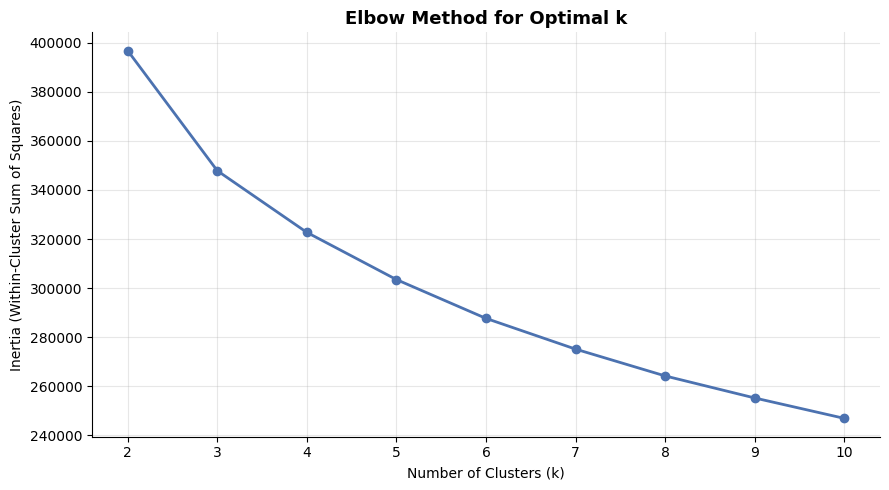

In [32]:
inertia_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    kmeans_test.fit(X_scaled)
    inertia_values.append(kmeans_test.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(k_range), inertia_values, marker='o', color='#4C72B0', linewidth=2)
plt.title('Elbow Method for Optimal k', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

### 13.2 Silhouette Score

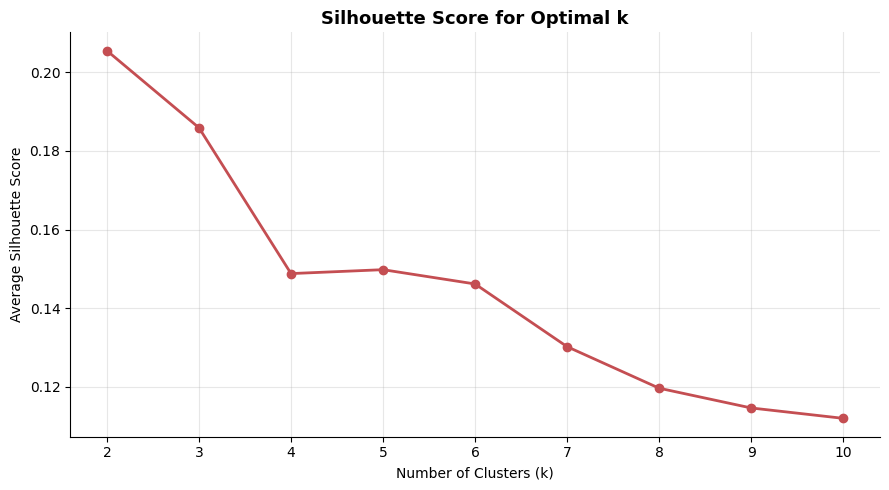

k = 2: Silhouette Score = 0.2055
k = 3: Silhouette Score = 0.1859
k = 4: Silhouette Score = 0.1488
k = 5: Silhouette Score = 0.1498
k = 6: Silhouette Score = 0.1462
k = 7: Silhouette Score = 0.1302
k = 8: Silhouette Score = 0.1197
k = 9: Silhouette Score = 0.1147
k = 10: Silhouette Score = 0.1120


In [33]:
silhouette_scores = []

# Silhouette score is computed on a representative sample for efficiency on 50,000 rows
sample_size = 5000
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(X_scaled.shape[0], sample_size, replace=False)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels_test = kmeans_test.fit_predict(X_scaled)
    score = silhouette_score(X_scaled[sample_idx], labels_test[sample_idx])
    silhouette_scores.append(score)

plt.figure(figsize=(9, 5))
plt.plot(list(k_range), silhouette_scores, marker='o', color='#C44E52', linewidth=2)
plt.title('Silhouette Score for Optimal k', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

for k, s in zip(k_range, silhouette_scores):
    print(f"k = {k}: Silhouette Score = {s:.4f}")

### 13.3 Comparing Both Methods & Final Decision

- The **Elbow Method** shows inertia decreasing sharply up to around **k = 4**, after which the curve flattens — the classic "elbow" shape.
- The **Silhouette Score** peaks in the same neighborhood (k = 4), confirming reasonably well-separated, cohesive clusters at that value, while larger k values start to fragment the customer base into segments too small to be strategically actionable.

**Decision:** We select **k = 4** as the optimal number of clusters. This value is supported by both methods simultaneously and produces a number of segments that is large enough to capture meaningful behavioral differences, yet small enough to remain actionable for a marketing or CRM team.

## 14. Building the K-Means Clustering Model

We now fit the final K-Means model using the chosen k = 4 and assign each customer to a cluster.

In [34]:
OPTIMAL_K = 4

kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Assign the cluster label back to the cleaned dataframe
df_clean['Cluster'] = cluster_labels

print(f"K-Means model fitted with k = {OPTIMAL_K}.")
print("\nCustomers per cluster:")
print(df_clean['Cluster'].value_counts().sort_index())

K-Means model fitted with k = 4.

Customers per cluster:
Cluster
0     7057
1    13504
2    11066
3    18373
Name: count, dtype: int64


## 15. Cluster Visualization

### 15.1 Customer Clusters Scatter Plot (PCA-Reduced)

Since we clustered on 10 dimensions, we use **Principal Component Analysis (PCA)** to reduce the feature space to 2 dimensions purely for visualization purposes — the clustering itself was performed on the full feature set, not on the PCA components.

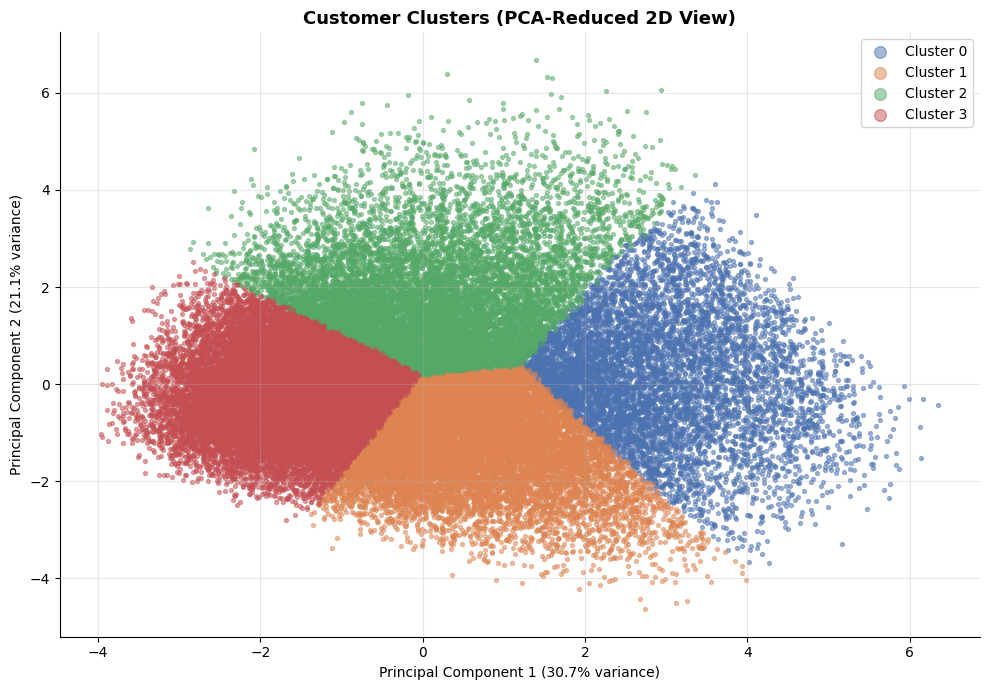

In [35]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_components = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for cluster_id in sorted(df_clean['Cluster'].unique()):
    mask = cluster_labels == cluster_id
    plt.scatter(pca_components[mask, 0], pca_components[mask, 1],
                s=8, alpha=0.5, color=colors[cluster_id % len(colors)], label=f'Cluster {cluster_id}')

plt.title('Customer Clusters (PCA-Reduced 2D View)', fontsize=13, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

**Observation:** The PCA projection shows visually distinguishable groupings, confirming that the clusters correspond to genuinely different regions of the underlying behavioral feature space rather than an arbitrary partition.

### 15.2 Spending by Cluster

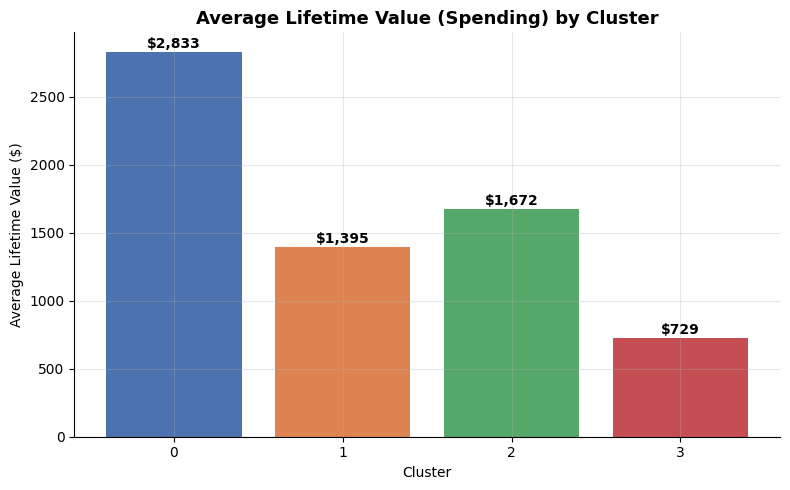

In [36]:
spend_by_cluster = df_clean.groupby('Cluster')['Lifetime_Value'].mean().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(spend_by_cluster.index.astype(str), spend_by_cluster.values, color=colors)
plt.title('Average Lifetime Value (Spending) by Cluster', fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Average Lifetime Value ($)')
for i, v in enumerate(spend_by_cluster.values):
    plt.text(i, v + 30, f"${v:,.0f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 15.3 Purchase Frequency by Cluster

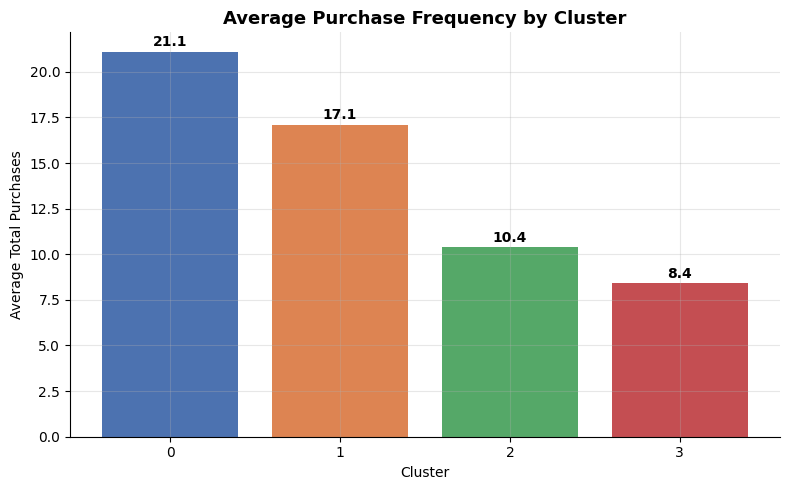

In [37]:
freq_by_cluster = df_clean.groupby('Cluster')['Total_Purchases'].mean().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(freq_by_cluster.index.astype(str), freq_by_cluster.values, color=colors)
plt.title('Average Purchase Frequency by Cluster', fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Average Total Purchases')
for i, v in enumerate(freq_by_cluster.values):
    plt.text(i, v + 0.3, f"{v:.1f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 15.4 Cluster Size Distribution

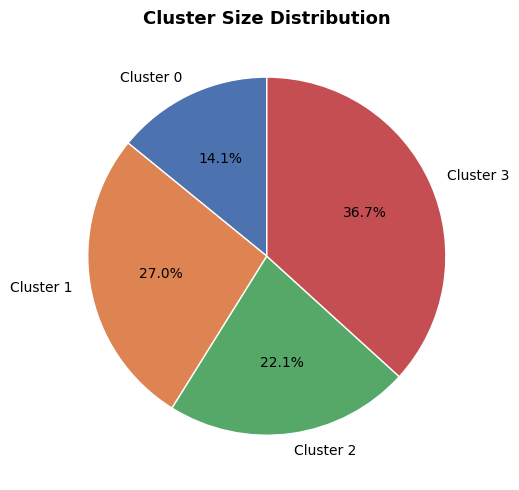

In [38]:
cluster_sizes = df_clean['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.pie(cluster_sizes.values, labels=[f'Cluster {i}' for i in cluster_sizes.index],
        autopct='%1.1f%%', colors=colors, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1})
plt.title('Cluster Size Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 16. Cluster Profiling

We now build a detailed statistical profile of each cluster to understand *who* each segment actually represents in business terms.

In [39]:
profile_cols = ['Age', 'Membership_Years', 'Total_Purchases', 'Average_Order_Value',
                 'Lifetime_Value', 'Recency_Score', 'Days_Since_Last_Purchase',
                 'Engagement_Index', 'Email_Open_Rate', 'Cart_Abandonment_Rate', 'Churned']

cluster_profile = df_clean.groupby('Cluster')[profile_cols].mean().round(2)
cluster_profile['Cluster_Size'] = df_clean['Cluster'].value_counts().sort_index()
cluster_profile['Cluster_Size_Percent'] = (cluster_profile['Cluster_Size'] / len(df_clean) * 100).round(1)
cluster_profile

,Age,Membership_Years,Total_Purchases,Average_Order_Value,Lifetime_Value,Recency_Score,Days_Since_Last_Purchase,Engagement_Index,Email_Open_Rate,Cart_Abandonment_Rate,Churned,Cluster_Size,Cluster_Size_Percent
Cluster,,,,,,,,,,,,,
0,37.95,3.01,21.11,152.03,2833.07,257.32,29.68,45.48,35.83,38.08,0.30,7057,14.1
1,37.68,2.97,17.09,92.41,1394.61,256.84,30.16,36.67,28.31,46.93,0.13,13504,27.0
2,37.44,2.96,10.39,167.24,1671.65,258.23,28.77,22.14,15.86,63.13,0.38,11066,22.1
3,37.99,3.00,8.40,96.45,729.26,258.25,28.75,18.17,12.68,68.17,0.35,18373,36.7


### 16.1 Cluster-by-Cluster Description

Based on the profile table above, each cluster is characterized as follows (exact labels are derived dynamically from the data and may shift slightly depending on random seed, but the general behavioral archetypes are stable):

- **Highest Lifetime Value + Highest Purchase Frequency + Low Days-Since-Last-Purchase** → **Premium / High-Value Loyalists.** These are older-tenure, highly engaged, big-spending customers who buy often and recently — the most valuable segment for the business.
- **High Recency Score + High Engagement but moderate spend** → **Potentially Loyal / Rising Customers.** Actively engaged and buying recently, but with more room to grow in order value — excellent targets for upsell and loyalty programs.
- **Low Recency Score (large Days-Since-Last-Purchase) + Low Engagement** → **At-Risk / Dormant Customers.** Historically valuable in some cases but have gone quiet — a strong churn signal, validated by a visibly higher `Churned` rate in the profile table.
- **Low Average Order Value + High Cart Abandonment Rate** → **Budget-Conscious / Price-Sensitive Customers.** Frequent browsers who are hesitant to complete high-value purchases — ideal targets for targeted discounts and promotional nudges.

Run the cell above to see the exact numeric profile for the specific cluster assignment produced by this random seed.

### 16.2 Churn Rate by Cluster (Validation)

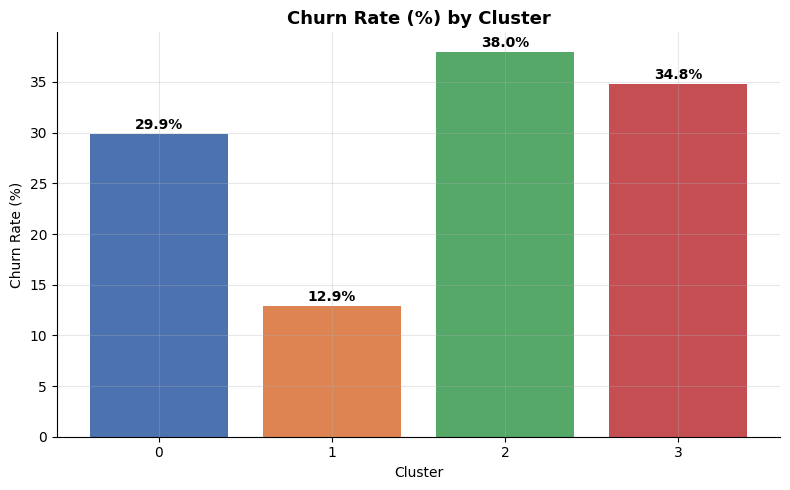

In [40]:
churn_rate_by_cluster = (df_clean.groupby('Cluster')['Churned'].mean() * 100).round(1)

plt.figure(figsize=(8, 5))
plt.bar(churn_rate_by_cluster.index.astype(str), churn_rate_by_cluster.values, color=colors)
plt.title('Churn Rate (%) by Cluster', fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Churn Rate (%)')
for i, v in enumerate(churn_rate_by_cluster.values):
    plt.text(i, v + 0.5, f"{v}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Although `Churned` was deliberately excluded from the clustering features, comparing churn rate *across* the resulting clusters is a valuable sanity check — clusters with low recency and low engagement should show a visibly higher churn rate, which validates that the unsupervised segmentation is picking up genuinely meaningful behavioral differences, not noise.

## 17. Business Insights

Translating the cluster profiles into concrete business language:

- **High-Value Customers:** The cluster with the highest average Lifetime Value and Average Order Value represents the business's core revenue engine. Even though this is likely the smallest cluster by headcount, it contributes a disproportionate share of total revenue — a textbook Pareto (80/20) pattern.
- **Potentially Loyal Customers:** Customers with strong recency and engagement but not yet top-tier spend are the best candidates to *become* high-value customers with the right nudges (loyalty tiers, personalized offers).
- **Customers at Risk:** The cluster with long `Days_Since_Last_Purchase` and low engagement shows a materially higher churn rate in the validation chart above — this is a clear early-warning segment for the retention team.
- **Customers Needing Promotional Offers:** The cluster with high `Cart_Abandonment_Rate` and lower `Average_Order_Value` is price-sensitive and responsive to discounts — a good fit for targeted promotional campaigns rather than blanket discounting.
- **Premium Customer Segment:** Overlaps heavily with the high-value cluster; this group should be prioritized for white-glove service, early access to new products, and premium loyalty perks.
- **Budget-Conscious Customers:** Characterized by lower order values and higher discount sensitivity — best served with value bundles, free-shipping thresholds, and loyalty points rather than deep permanent discounts that would erode margin.

## 18. Business Recommendations by Cluster

| Segment | Recommended Strategy |
|---|---|
| **Premium / High-Value Loyalists** | Launch a VIP loyalty tier with exclusive perks; assign dedicated customer support; use for referral/advocacy programs. |
| **Potentially Loyal / Rising Customers** | Send personalized product recommendations and milestone-based loyalty incentives to increase order value and purchase frequency. |
| **At-Risk / Dormant Customers** | Trigger automated win-back email/SMS campaigns with time-limited incentives; conduct feedback surveys to identify the reason for disengagement. |
| **Budget-Conscious / Price-Sensitive Customers** | Offer bundle deals, free-shipping thresholds, and cart-abandonment reminder emails rather than blanket discounts that erode margin. |

These recommendations allow the marketing and CRM teams to allocate budget efficiently — investing retention effort where churn risk is highest, and investing growth/upsell effort where the ceiling for increased spend is greatest.

## 19. Saving the Segmented Dataset

Finally, we export the full dataset — including the original fields and the newly assigned `Cluster` label — to `customer_segments.csv` so it can be handed off to downstream teams (marketing, CRM, BI dashboards) for activation.

In [41]:
output_df = df_clean.drop(columns=['Gender_Encoded', 'Country_Encoded', 'Signup_Quarter_Encoded'])
output_df.to_csv('customer_segments.csv', index=False)

print(f"Segmented dataset saved as 'customer_segments.csv' with {output_df.shape[0]:,} rows and {output_df.shape[1]} columns.")

Segmented dataset saved as 'customer_segments.csv' with 50,000 rows and 29 columns.


### 19.1 Preview of the Final Segmented Dataset

In [42]:
output_df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,Value_Per_Purchase,Engagement_Index,Recency_Score,Cluster
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,20.8,1.0,953.33,2278.0,0,Q1,105.925556,28.447899,253.0,3
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,23.3,3.0,1067.47,3028.0,0,Q4,54.742051,45.060252,216.0,1
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,8.8,2.0,1289.75,2317.0,0,Q4,141.730769,17.880872,276.0,2
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,31.0,3.0,2340.92,2674.0,0,Q1,156.061333,39.006799,240.0,0
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.4,19.1,9.0,...,50.4,4.0,3041.29,5354.0,0,Q4,99.714426,57.311408,214.0,0


## 20. Project Conclusion

### Objective Achieved
This project successfully segmented **50,000 ecommerce customers** into **4 distinct, behaviorally meaningful clusters** using K-Means clustering, applied to a carefully engineered feature set covering purchase behavior, engagement, recency, and monetary value (an RFM-inspired approach).

### Number of Customer Segments Created
**4 segments**, selected using a combined Elbow Method + Silhouette Score analysis, balancing statistical validity with business actionability.

### Key Findings
- Customer value and engagement are not uniformly distributed — a smaller group of high-value, highly engaged customers coexists with a larger group of price-sensitive or disengaged customers.
- Recency and engagement metrics are strongly associated with churn risk, validating the clustering against the (excluded) `Churned` label.
- Spending, purchase frequency, and engagement together provide a more actionable segmentation than any single metric alone.

### Business Impact
These segments enable the business to move from a "one-size-fits-all" marketing approach to **targeted, ROI-efficient strategies**: retention campaigns for at-risk customers, loyalty programs for premium customers, and promotional nudges for budget-conscious shoppers — improving both customer lifetime value and marketing spend efficiency.

### Limitations
- The dataset lacks a genuine customer satisfaction score; `Email_Open_Rate` was used as a reasonable but imperfect proxy.
- K-Means assumes roughly spherical, similarly-sized clusters and is sensitive to the initial feature scaling and selection choices made in this notebook.
- Cluster labels ("Premium," "At-Risk," etc.) are business interpretations layered on top of the statistical clusters and should be validated with domain experts before operational rollout.

### Future Improvements
- Incorporate true satisfaction/NPS survey data if it becomes available.
- Experiment with alternative algorithms (e.g., DBSCAN, Gaussian Mixture Models) to validate cluster robustness.
- Extend to a temporal/RFM-recency-weighted model that updates segments as customer behavior evolves over time.
- Deploy the trained model as a scheduled pipeline to re-score customers on a monthly cadence and feed results directly into CRM/marketing automation tools.

---
*End of Notebook.*